# MAGI — Example Usage (v0.8.2)

A runnable, fully-commented walkthrough of the whole MAGI pipeline on **synthetic
data**: load → preprocess → detect spectral lines → build dataset → train →
checkpoint → reload → generate → validate → export a Geant4 source file.

It uses the **v0.8 mixture-energy head**
(`CVAE_MixEnergy_ContPhi_TaskAdaptive`), which is what the v0.8.2 beta is. The
synthetic source deliberately contains two narrow spectral lines on top of a
power-law continuum, so the line machinery is actually exercised rather than
just mentioned.

Everything here is small and fast — a few thousand events and a handful of
epochs — so it runs end to end in a couple of minutes on a CPU. The numbers it
produces are therefore **not** meaningful physics; the point is that every step
runs and connects to the next.

> **This release is a beta.** MAGI v0.8.2 reproduces the joint phase-space
> distribution (energy–position–direction correlations) and the energy continuum
> to within its acceptance bars. It does **not** yet reproduce spectral-line
> *intensities* — measured recovery runs 0.7×–4.9× and is unstable across seeds.
> Line *positions* are reliable. See `docs/manual/magi_manual.pdf` §7 before
> quoting any number from a real run.

In [1]:
# CPU-only must be set BEFORE magi is imported: importing magi pulls in
# tensorflow_probability, which initializes the device, after which
# set_visible_devices no longer takes effect.
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import numpy as np
import pandas as pd
import magi

magi.initialize_environment(seed=42, cpu_only=True, quiet=True)
magi.print_tf_info()

TensorFlow version: 2.16.2
Keras version     : 3.12.1

Physical devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU devices     : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Logical devices : [LogicalDevice(name='/device:CPU:0', device_type='CPU')]


## 1. A synthetic source

MAGI reads whitespace-delimited Geant4 crossing files with
`magi.load_detector_table`. Rather than ship a data file, we build an
equivalent DataFrame in memory.

The source below is a sphere of radius 20 mm. Each event gets:

- a **particle type** (`gamma`, `e-`, `mu-`),
- an **energy** drawn from a power-law continuum **plus two narrow lines**,
- a **position** on the sphere surface,
- a **direction**, deliberately **correlated with energy** — high-energy events
  travel preferentially in −z. That correlation is the thing the conditional
  prior exists to reproduce, and we measure it at the end.

MAGI parametrizes both position and direction by a **global-frame** polar
cosine plus an azimuth: `u_r`/`phi_r` for the crossing point, `u_v`/`phi_v` for
the direction, where `u_v` is simply the z-component of the unit direction
vector. Building the source directly in those variables (rather than in a local
surface frame) keeps the injected correlation intact through preprocessing.

The two lines are placed at 8.0 keV and 511 keV and are **exactly
monoenergetic**, matching how Geant4 emits fluorescence and annihilation lines
in raw crossing data: no detector response has been applied at this stage.

In [2]:
rng = np.random.default_rng(42)

N_CONT = 6000            # continuum events
N_LINE_A, N_LINE_B = 700, 500
E_LINE_A = 0.00800571    # MeV — a Cu K-alpha1-like fluorescence line
E_LINE_B = 0.510999      # MeV — e+e- annihilation

center = (0.0, 0.0, -50.0)   # mm
R = 20.0                     # mm

# --- energies: power-law continuum spanning ~4 decades, plus two exact lines
u = rng.uniform(0.0, 1.0, N_CONT)
E_cont = 1e-3 * (1.0 / (1.0 - 0.999 * u)) ** 0.6          # MeV, 1e-3 .. ~1e1
E_cont = np.clip(E_cont, 1e-3, 20.0)

E = np.concatenate([
    E_cont,
    np.full(N_LINE_A, E_LINE_A),      # exactly monoenergetic - see the note above
    np.full(N_LINE_B, E_LINE_B),
])
N = E.size
order = rng.permutation(N)
E = E[order]

# --- particle type: energy-dependent, so the type conditioning has real work
p_gamma = np.clip(0.7 - 0.15 * np.log10(E / 1e-3), 0.05, 0.9)
which = rng.uniform(size=N)
ParticleName = np.where(which < p_gamma, "gamma",
                np.where(which < p_gamma + 0.25, "e-", "mu-"))

# --- position: uniform on the sphere surface.
# MAGI parametrizes position by u_r = z-component of the unit radius vector
# (i.e. cos of the polar angle) and phi_r = its azimuth. Both are GLOBAL-frame,
# not a local surface frame - see build_physical_features.
u_r = rng.uniform(-1.0, 1.0, N)
phi_r = rng.uniform(0.0, 2 * np.pi, N)
sin_r = np.sqrt(1.0 - u_r ** 2)
X = center[0] + R * sin_r * np.cos(phi_r)
Y = center[1] + R * sin_r * np.sin(phi_r)
Z = center[2] + R * u_r

# --- direction: CORRELATED WITH ENERGY, which is the point of this example.
# Direction is parametrized the same way: u_v = z-component of the unit
# direction vector, phi_v its azimuth. We make u_v depend on energy, so
# high-energy events travel preferentially in -z.
forward = np.clip(0.15 + 0.30 * np.log10(E / 1e-3), 0.0, 1.0)
u_v = np.clip(rng.normal(loc=-forward, scale=0.35, size=N), -0.999, 0.999)
phi_v = rng.uniform(0.0, 2 * np.pi, N)
sin_v = np.sqrt(1.0 - u_v ** 2)

Vx = sin_v * np.cos(phi_v)
Vy = sin_v * np.sin(phi_v)
Vz = u_v                      # by construction, this is MAGI's u_v

print("injected corr(log10 E, u_v) =",
      round(float(np.corrcoef(np.log10(E), u_v)[0, 1]), 3))

df = pd.DataFrame({
    "ParticleName": ParticleName,
    "Energy": E,
    "X": X, "Y": Y, "Z": Z,
    "Vx": Vx, "Vy": Vy, "Vz": Vz,
    "PrimBool": rng.integers(0, 2, N),
})

magi.report_basic_table_checks(df)

injected corr(log10 E, u_v) = -0.456
N rows: 7200
  ParticleName    Energy          X          Y          Z        Vx        Vy  \
0          mu-  0.510999 -18.433994   1.955303 -57.507640  0.027374 -0.035350   
1           e-  0.001124  14.335667  13.258219 -45.674694 -0.439011  0.853172   
2        gamma  0.001383 -18.647080  -5.980957 -45.936187 -0.426886 -0.904075   
3        gamma  0.008006  15.415091  -8.884818 -59.134276 -0.977492  0.101311   
4          mu-  0.510999   8.623824   0.207187 -31.955978  0.044696  0.001117   

         Vz  PrimBool  
0 -0.999000         0  
1 -0.281722         0  
2  0.020415         1  
3 -0.185057         1  
4 -0.999000         0  

NaN per column:
 ParticleName    0
Energy          0
X               0
Y               0
Z               0
Vx              0
Vy              0
Vz              0
PrimBool        0
dtype: int64

PrimBool present: n_primaries=3610 n_generated=7200 primary_fraction=0.5013888888888889


## 2. Physical features

`build_physical_features` converts raw Cartesian `X,Y,Z,Vx,Vy,Vz` into the
sphere-surface parametrization the model works in: radial position
(`u_r`, `phi_r`) and direction (`u_v`, `phi_v`). It also measures the primary
fraction used for flux normalization.

`source_type` decides what "primary" means: `"cosmic_ray"` uses `PrimBool == 1`;
`"radioactive"` uses `CreatorProcessName == "RadioactiveDecay"`, because for a
source embedded in bulk material the literal Geant4 primary is the decaying
nucleus, which never propagates. **Choosing wrongly does not raise** — it
silently produces a wrong normalization factor.

In [3]:
prep = magi.build_physical_features(
    df, center=center, radius=R, source_type="cosmic_ray")
magi.print_physical_summary(prep)


--- RAW sphere check ---
r: mean = 20.0 std = 2.4798405215368675e-15 min = 19.99999999999999 max = 20.00000000000001
Mean absolute deviation from R: 1.4220723364309783e-15

--- RAW direction norm check ---
||v||: mean = 1.0 std = 5.641358202589059e-17 min = 0.9999999999999998 max = 1.0000000000000002
Mean absolute deviation from 1: 2.795603255063068e-17

--- PROJECTED sphere check ---
r_proj: mean = 19.999999999999 std = 2.2300963547255134e-15 min = 19.999999999998998 max = 19.999999999999005
Mean absolute deviation from R: 9.985340949154104e-13

--- RENORMALIZED direction check ---
||vhat||: mean = 0.9999999999989999 std = 9.33108529934147e-17 min = 0.9999999999989997 max = 0.9999999999990002
Mean absolute deviation from 1: 1.0000542061128215e-12

--- Energy check ---
E: min = 0.0010001885105053656 max = 0.510999 #E<=0 = 0

--- u_r check ---
u_r: min = -0.9999615209667925 max = 0.9999649768844281 mean = 0.001367702843999642 std = 0.5800162417969451

--- u_v check ---
u_v: min = -0.99

## 3. Spectral lines — detect *before* building the feature frame

This is the part of the pipeline most specific to v0.8, and the ordering
matters. Lines are detected on the **raw energies**, on their own fine binning,
*before* `build_feature_dataframe` runs. The feature frame's binning is a
separate, coarser thing: with the mixture head it no longer constrains where a
line can be *placed*, only how the continuum is described.

A candidate table would normally come from
`magi.load_candidate_energy_lines("CandidateLines/....json")`, built from a GDML
mass model by `tools/build_candidate_lines_from_geant4.py`. Here we write the
two candidates by hand.

`refine_bin_width_mev` refines each detected peak to sub-bin precision. On a log
grid spanning many decades a detection bin can be hundreds of eV wide — far
broader than a real line — so the bin centre is a poor position estimate.

In [4]:
candidate_lines = [
    {"label": "synthetic Cu K-alpha1", "energy_mev": E_LINE_A, "origin": "instrumental"},
    {"label": "synthetic e+e- 511",    "energy_mev": E_LINE_B, "origin": "instrumental"},
]

RESOLUTION_EV = 4.0   # X-IFU-like; the GENERATIVE line width, see below

E_raw = prep["features"]["Energy"].to_numpy()

res = magi.detect_energy_lines(
    E_raw,
    binning_mode="log_fixed_count", n_bins=256,
    prominence_factor=3.0, window=5,
    candidate_lines=candidate_lines,
    refine_bin_width_mev=RESOLUTION_EV * 1e-6,
)
magi.print_detected_energy_lines(res)

# Keep only lines with enough events to model. On real data this is the 5-sigma
# Poisson floor discussion in the manual; here a plain count filter.
matched = [m for m in res["matched_lines"] if m["count"] >= 100]

# Doublets closer together than one detection bin never become separate peaks,
# so re-measure any unmatched candidate at eV resolution and confirm the real
# ones. (Nothing new to find in this toy source; on real data it recovers
# e.g. Cu K-alpha2, 21 eV from K-alpha1.)
matched += magi.confirm_unresolved_candidate_lines(
    E_raw, candidate_lines, matched, resolution_ev=RESOLUTION_EV)

print("\nmodelled lines:", [m["label"] for m in matched])


--- Energy line detection ---
events: 7200  bins: 256  mode: log_fixed_count
candidate lines: 2  detected peaks: 5  matched: 1

Matched lines:
  synthetic Cu K-alpha1 (instrumental          ) expected=0.008006 MeV detected=0.008006 MeV delta=+0.000000 MeV  count=708

Expected-but-undetected candidates (likely Compton-smeared / below prominence):
  synthetic e+e- 511   (instrumental          ) expected=0.510999 MeV

Unmatched detected peaks (possible unknown/uncatalogued lines):
  bin=  125  E=0.021273 MeV  count=5
  bin=  128  E=0.022886 MeV  count=4
  bin=  140  E=0.030657 MeV  count=4
  bin=  151  E=0.040077 MeV  count=4

modelled lines: ['synthetic Cu K-alpha1', 'synthetic e+e- 511']


## 4. Feature dataframe

`build_feature_dataframe` bins energy and fits the quantile geometry
transforms. Two settings matter here:

- `geometry_transform="quantile_u_r_u_v_phi_r_phi_v"` is the v0.7.2+ layout.
  This string is a **contract**: it is persisted in the checkpoint metadata and
  must match between training and generation. A mismatch does not raise, it
  produces physically wrong output.
- `energy_transform="log10"` gives the mixture head the target
  `y = log10(E/MeV)` it models in.

In [5]:
feature_pack = magi.build_feature_dataframe(
    prep,
    energy_binning_mode="log_fixed_count",
    n_bins=64,                 # small, because this toy source is small
    min_counts=5,
    geometry_transform="quantile_u_r_u_v_phi_r_phi_v",
    n_quantiles=1000,
    random_state=42,
    energy_transform="log10",
)
magi.report_feature_dataframe(feature_pack)


feat shape: (7200, 8)
geometry_transform: quantile_u_r_u_v_phi_r_phi_v

First rows:
  ParticleName  E_idx     u_r_q     u_v_q   phi_r_q   phi_v_q  energy_y  \
0          mu-     63 -0.486377 -5.199337  2.079467 -0.350808 -0.291580   
1           e-      1  0.260760  0.009716  0.295232  0.941492 -2.949221   
2        gamma      3  0.242572  0.796064 -1.647358 -0.914746 -2.859256   
3        gamma     21 -0.604209  0.253445 -0.196252  2.157500 -2.096600   
4          mu-     63  1.672719 -5.199337  0.021423  0.020930 -0.291580   

   PrimBool  
0         0  
1         0  
2         1  
3         1  
4         0  

--- Finite check ---
Rows with NaN/Inf: 0

--- Feature ranges ---
     E_idx : 0  63
     u_r_q : -5.199337482452393  5.199337482452393
     u_v_q : -5.199337482452393  5.199337482452393
   phi_r_q : -5.199337482452393  5.199337482452393
   phi_v_q : -5.199337482452393  5.199337482452393
  energy_y : -2.999918222427368  -0.2915799617767334
  PrimBool : 0  1

--- Quantile geome

## 5. Gate targets and pinned line widths

Two distinct uses of the detector resolution, which are easy to conflate:

1. **`build_gate_targets`** builds the *training label* saying which real events
   belong to which mixture component. `bandwidth_mode="resolution"` uses a
   Gaussian kernel of the detector FWHM for that decision.
2. **`line_logsigma_from_resolution`** sets the model's pinned *generative*
   line width — how wide the lines it produces are.

The lines in this synthetic source are exactly monoenergetic, which suggests an
exact-match label would be better, and `bandwidth_mode="exact"` exists for that.
**On real data it measured worse**: it did not fix the line it was built for, it
broke a previously passing line, and it pushed the coupling residual out of
band. `"resolution"` is the default and is what every confirmed result used.
See `docs/v0.8.1_line_truth.md` §14.2.

The gate targets then ride into the dataset as extra feature columns.

In [6]:
E_full = feature_pack["filtered_prep"]["features"]["Energy"].to_numpy()

gate_targets = magi.build_gate_targets(
    E_full, feature_pack["energy_bins"], matched,
    bandwidth_mode="resolution",
    bandwidth_fwhm_mev=RESOLUTION_EV * 1e-6,
)
print("gate_targets shape:", gate_targets.shape,
      "= [continuum, line_1..line_L] per event")
print("mean routing fraction per component:", gate_targets.mean(axis=0).round(5))

line_positions_y = np.log10(
    [m["candidate_energy_mev"] for m in matched]).astype(np.float32)
line_logsigma = magi.line_logsigma_from_resolution(
    10.0 ** line_positions_y, RESOLUTION_EV, fwhm=True)

print("line positions (y = log10 E/MeV):", line_positions_y)
print("pinned line log-sigmas          :", np.asarray(line_logsigma).round(6))

gate_targets shape: (7200, 3) = [continuum, line_1..line_L] per event
mean routing fraction per component: [0.8362  0.09571 0.06808]
line positions (y = log10 E/MeV): [-2.0966     -0.29157996]
pinned line log-sigmas          : [ -9.292113 -13.448325]


## 6. Dataset build

Filter rare particle types, split (stratified on type), scale, build the type
one-hot conditioning and per-type loss weights, then the `tf.data` pipelines.

`scale_cols=()` is deliberate: the quantile-transformed geometry columns are
already standardized by their own transform, and scaling them twice is wrong.

In [7]:
feat = feature_pack["feat"].copy()
for j in range(gate_targets.shape[1]):
    feat[f"gate_target_{j}"] = gate_targets[:, j]

cont_cols = ("u_r_q", "u_v_q", "phi_r_q", "phi_v_q", "energy_y") + tuple(
    f"gate_target_{j}" for j in range(gate_targets.shape[1]))

dataset_pack = magi.filter_particle_types_continuous_geometry(
    feat=feat, prob_threshold=1e-5, cont_cols=cont_cols,
    normalization=prep.get("normalization"))

split_pack = magi.split_feature_data(dataset_pack, random_state=42)
magi.report_split_summary(split_pack, dataset_pack["n_types"])

scaled_pack = magi.scale_continuous_features(split_pack, scale_cols=())
condition_pack = magi.build_conditioning_and_weights(
    scaled_pack, dataset_pack["n_types"],
    idx_to_type=dataset_pack["idx_to_type"], alpha=0.5)
magi.report_conditioning(condition_pack, dataset_pack["n_types"])

ds_pack = magi.build_tf_datasets(condition_pack, batch_size=256)
magi.report_tf_datasets(ds_pack)

Train: (5040, 8) Val: (1080, 8) Test: (1080, 8)

Type distribution check:
Train: [0.62519841 0.25238095 0.12242063]
Val  : [0.625      0.25185185 0.12314815]
Test : [0.625      0.25277778 0.12222222]

cond_train shape: (5040, 3)
cond_val shape  : (1080, 3)
cond_test shape : (1080, 3)

Example one-hot rows:
tf.Tensor(
[[0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]], shape=(5, 3), dtype=float32)

Class fractions in train:
gamma: 0.6251984
e-: 0.25238097
mu-: 0.12242063

Class counts: [3151. 1272.  617.]
Class frequencies: [0.62519841 0.25238095 0.12242063]
Class weights: [0.6206332  0.97682244 1.4025444 ]

Datasets ready.
Dataset mode: continuous_geometry
Train batches: 20
Val batches  : 5
Test batches : 5

Batch check:
X_cont batch shape: (256, 8)
E_idx batch shape : (256,)
cond batch shape  : (256, 3)


## 7. Per-type zone probabilities

v0.8.2's `prior_zone_conditioning` widens what the learned prior is conditioned
on, from the particle-type one-hot alone to `[type, zone]`, where zone is the
continuum/line routing target.

Why it is needed: the gate is trained on `z ~ q(z|x)` but generation draws
`z ~ p(z|cond)`. Without the zone in `cond`, the prior has no way to express
which mixture component an event belongs to, so at generation time rare lines
get routed by whatever the type marginal happens to imply. On the real
cosmic-ray source this change moved Al K-alpha1 from 0.702 ± 0.290 to
0.959 ± 0.025 while leaving coupling intact.

At generation time the zone is sampled from each type's empirical frequency,
which is what `zone_probs` records.

In [8]:
n_zones = gate_targets.shape[1]
zone_cols = dataset_pack["X_cont_raw"][:, -n_zones:]
y_type = dataset_pack["y_type"]

zone_probs = np.zeros((dataset_pack["n_types"], n_zones), dtype=np.float64)
for t in range(dataset_pack["n_types"]):
    mask = (y_type == t)
    row = zone_cols[mask].mean(axis=0) if mask.any() else np.zeros(n_zones)
    s = row.sum()
    zone_probs[t] = (row / s) if s > 0 else np.eye(n_zones)[0]

print("zone_probs [type x (continuum, line_1..line_L)]:")
for t in range(dataset_pack["n_types"]):
    print(f"  {dataset_pack['idx_to_type'][t]:>8s}",
          np.array2string(zone_probs[t], precision=5))

zone_probs [type x (continuum, line_1..line_L)]:
     gamma [0.87781 0.08669 0.0355 ]
        e- [0.84141 0.10031 0.05827]
       mu- [0.61318 0.13227 0.25455]


## 8. Build and train the v0.8 model

`CVAE_MixEnergy_ContPhi_TaskAdaptive` keeps v0.7.2's geometry heads and replaces
the categorical energy head with a gated mixture of a continuum density and
fixed-position line components.

The settings that matter:

| Setting | Why |
|---|---|
| `continuum_mode="flow"` | A single Gaussian cannot represent a multi-decade continuum. |
| `continuum_flow_warp="cdf"` | Pre-warps the flow input by the empirical CDF, so spline knots go where the events are. |
| `energy_flow_condition="z_cond"` | Conditions the continuum flow on both latent and conditioning. |
| `prior="coupling"` | The learned conditional prior. This is what makes the correlations come out right. |
| `prior_zone_conditioning=True` | Section 7 above. |
| `gate_focal_gamma=1.0` | Focal weighting so rare lines get routed. **Use 1** — at γ ≥ 2 the gate digs the continuum out from between the lines. |

A real run is 40 epochs and takes ~90 minutes on CPU. Here: 8 epochs on a tiny
sample, purely to show the loop runs and the loss moves.

In [9]:
# CDF pre-warp knots for the continuum flow, fitted on the energy target.
ey = feat["energy_y"].to_numpy()
warp_yk, warp_zk = magi.fit_cdf_warp_knots(ey, n_knots=64, eps=1e-4)

model = magi.CVAE_MixEnergy_ContPhi_TaskAdaptive(
    n_types=dataset_pack["n_types"],
    latent_dim=4,
    hidden=(64, 64),
    line_positions_y=line_positions_y,
    line_logsigma_init=line_logsigma,
    line_logsigma_trainable=False,   # widths are pinned, not fitted
    continuum_mode="flow",
    continuum_flow_warp="cdf",
    continuum_flow_warp_y_knots=warp_yk,
    continuum_flow_warp_z_knots=warp_zk,
    continuum_flow_bins=16,
    continuum_flow_transforms=3,
    energy_flow_condition="z_cond",
    prior="coupling",
    prior_zone_conditioning=True,
    zone_probs=zone_probs,
    gate_focal_gamma=1.0,
    w_gate_aux=2.0,
    type_weights=condition_pack["type_weights"],
)

magi.compile_model(model, learning_rate=2e-3, optimizer="adam")

<CVAE_MixEnergy_ContPhi_TaskAdaptive name=cvae__mix_energy__cont_phi__task_adaptive, built=False>

In [10]:
history = magi.fit_model(
    model, ds_pack["train_ds"], ds_pack["val_ds"],
    epochs=8, callbacks=magi.build_default_callbacks(early_patience=20),
    verbose=2,
)

Epoch 1/8


20/20 - 15s - 734ms/step - continuum_balance: 0.0000e+00 - continuum_repulsion: 0.0000e+00 - energy_mixture_nll: -1.5002e+00 - flow_line_repulsion: 0.0000e+00 - gate_aux_loss: 0.4144 - kl: 0.2425 - loss: 1.2812 - nll: 1.6274 - phi_r_nll: 0.5060 - phi_v_nll: 0.5051 - rec: 1.2153 - sigma_reg: 0.0174 - ur_nll: 0.4899 - uv_nll: 0.7978 - val_continuum_balance: 0.0000e+00 - val_continuum_repulsion: 0.0000e+00 - val_energy_mixture_nll: -1.7734e+00 - val_flow_line_repulsion: 0.0000e+00 - val_gate_aux_loss: 0.3307 - val_kl: 0.3546 - val_loss: 0.7182 - val_nll: 0.9523 - val_phi_r_nll: 0.4804 - val_phi_v_nll: 0.5239 - val_rec: 0.6309 - val_sigma_reg: 0.0163 - val_ur_nll: 0.4771 - val_uv_nll: 0.5830 - learning_rate: 0.0020


Epoch 2/8


20/20 - 0s - 18ms/step - continuum_balance: 0.0000e+00 - continuum_repulsion: 0.0000e+00 - energy_mixture_nll: -1.8387e+00 - flow_line_repulsion: 0.0000e+00 - gate_aux_loss: 0.2675 - kl: 0.6306 - loss: 0.4363 - nll: 0.5686 - phi_r_nll: 0.5026 - phi_v_nll: 0.5057 - rec: 0.2946 - sigma_reg: 0.0156 - ur_nll: 0.4505 - uv_nll: 0.4134 - val_continuum_balance: 0.0000e+00 - val_continuum_repulsion: 0.0000e+00 - val_energy_mixture_nll: -1.9925e+00 - val_flow_line_repulsion: 0.0000e+00 - val_gate_aux_loss: 0.2287 - val_kl: 0.9075 - val_loss: 0.0869 - val_nll: 0.1475 - val_phi_r_nll: 0.4628 - val_phi_v_nll: 0.5132 - val_rec: -1.0927e-01 - val_sigma_reg: 0.0147 - val_ur_nll: 0.3226 - val_uv_nll: 0.3840 - learning_rate: 0.0020


Epoch 3/8


...

Epoch 7/8


20/20 - 0s - 20ms/step - continuum_balance: 0.0000e+00 - continuum_repulsion: 0.0000e+00 - energy_mixture_nll: -2.2127e+00 - flow_line_repulsion: 0.0000e+00 - gate_aux_loss: 0.0379 - kl: 4.4073 - loss: -1.7541e+00 - nll: -3.0478e+00 - phi_r_nll: 0.5098 - phi_v_nll: 0.5055 - rec: -2.6447e+00 - sigma_reg: 0.0091 - ur_nll: -1.3668e+00 - uv_nll: -5.5935e-01 - val_continuum_balance: 0.0000e+00 - val_continuum_repulsion: 0.0000e+00 - val_energy_mixture_nll: -2.1274e+00 - val_flow_line_repulsion: 0.0000e+00 - val_gate_aux_loss: 0.0310 - val_kl: 4.7942 - val_loss: -9.0327e-01 - val_nll: -2.0522e+00 - val_phi_r_nll: 0.4844 - val_phi_v_nll: 0.5157 - val_rec: -1.8722e+00 - val_sigma_reg: 0.0100 - val_ur_nll: -6.5965e-01 - val_uv_nll: -3.2724e-01 - learning_rate: 0.0020


Epoch 8/8


20/20 - 0s - 22ms/step - continuum_balance: 0.0000e+00 - continuum_repulsion: 0.0000e+00 - energy_mixture_nll: -2.1639e+00 - flow_line_repulsion: 0.0000e+00 - gate_aux_loss: 0.0309 - kl: 4.4137 - loss: -1.5267e+00 - nll: -2.7644e+00 - phi_r_nll: 0.5074 - phi_v_nll: 0.5030 - rec: -2.4192e+00 - sigma_reg: 0.0097 - ur_nll: -1.1908e+00 - uv_nll: -4.8187e-01 - val_continuum_balance: 0.0000e+00 - val_continuum_repulsion: 0.0000e+00 - val_energy_mixture_nll: -2.3137e+00 - val_flow_line_repulsion: 0.0000e+00 - val_gate_aux_loss: 0.0394 - val_kl: 4.3287 - val_loss: -1.9345e+00 - val_nll: -3.2036e+00 - val_phi_r_nll: 0.4799 - val_phi_v_nll: 0.5206 - val_rec: -2.8093e+00 - val_sigma_reg: 0.0091 - val_ur_nll: -1.4166e+00 - val_uv_nll: -5.5262e-01 - learning_rate: 0.0020


Restoring model weights from the end of the best epoch: 8.


`print_model_structure` prints the generative structure with the formulas the
code actually implements, the configured line table, and the parameter counts —
useful for confirming the model is the one you meant to build.

In [11]:
magi.print_model_structure(model, summaries=False)


===== MAGI MODEL STRUCTURE =====
Model class   = CVAE_MixEnergy_ContPhi_TaskAdaptive
latent_dim    = 4
n_types       = 3
n_lines       = 2 (mixture energy head)
continuum     = flow (warp=cdf, K=1)
prior         = coupling
y_cont_dim    = 8

--- Generative model (what sampling actually does) ---
  cond c   : particle-type one-hot, dim 3
  1. z ~ p(z | c)      learned coupling-flow prior, z in R^4
  2. h = decoder(z, c) shared stem -> per-variable branches
  3. y ~ p(y | h)      factorized over the physical variables:
       energy_y = log10(E/MeV) ~ gate-weighted mixture (below)
       u_r_q    ~ N(mu(h), sigma(h))   (quantile-transformed)
       u_v_q    ~ N(mu(h), sigma(h))   (quantile-transformed)
       phi_r_q  ~ N(mu(h), sigma(h))   (quantile-transformed)
       phi_v_q  ~ N(mu(h), sigma(h))   (quantile-transformed)
  4. invert the quantile transforms -> physical (x,y,z, vx,vy,vz, E)

--- Latent prior p(z | c) ---
  mode : coupling (learned, conditional)
  6 affine coupling laye

## 9. Save the run

`save_final_trained_model` writes weights, config, metadata, history, task
weights and a human-readable summary as **one unit**. Generation needs the
config and metadata as much as the weights, so copy or move them together.

Pass `model.to_generation_config()` rather than a hand-written dict: for v0.8
heads the loader *requires* every key it emits and raises on a missing one.
That guard exists because the old `.get(key, default)` behaviour silently
rebuilt a different architecture — the defaults select a code path, not just a
layer shape, so generation was wrong instead of failing.

In [12]:
import tempfile, joblib, os

SAVE_DIR = os.path.join(tempfile.gettempdir(), "magi_example_run")
MODEL_NAME = "example_mix"

preprocessing_metadata = {
    "source": "Example_Usage.ipynb synthetic toy source",
    "geometry_transform": "quantile_u_r_u_v_phi_r_phi_v",
    "energy_transform": "log10",
    "energy_bins": [float(b) for b in feature_pack["energy_bins"]],
    # type_probs/idx_to_type/n_types are what save_routing_circuit (Section 14)
    # reads back from the checkpoint alone later - without them here it would
    # fail with a bare KeyError instead of the informative error it raises for
    # a genuinely non-zone-conditioned run.
    "type_probs": np.asarray(dataset_pack["type_probs"]).tolist(),
    "idx_to_type": dataset_pack["idx_to_type"],
    "n_types": int(dataset_pack["n_types"]),
    "center": list(center),
    "radius": R,
    "resolution_ev": RESOLUTION_EV,
    "matched_lines": [
        {"label": m["label"], "candidate_energy_mev": m["candidate_energy_mev"]}
        for m in matched
    ],
    "cont_cols": list(cont_cols),
}

paths = magi.save_final_trained_model(
    model=model,
    save_dir=SAVE_DIR,
    model_name=MODEL_NAME,
    history=history,
    model_config=model.to_generation_config(),
    preprocessing_metadata=preprocessing_metadata,
    normalization_metadata=prep.get("normalization"),
    notes="Example_Usage.ipynb synthetic walkthrough",
)

# The fitted transformers are part of the same unit.
qt = feature_pack["quantile_transformers"]
joblib.dump(qt, os.path.join(SAVE_DIR, f"{MODEL_NAME}_quantile_transformers.joblib"))

print("\nrun directory:", SAVE_DIR)
for f in sorted(os.listdir(SAVE_DIR)):
    print("  ", f)

Saved final trained model to: /var/folders/l7/67sx0h9j2zz3l3b80sx34dj00000gn/T/magi_example_run

run directory: /var/folders/l7/67sx0h9j2zz3l3b80sx34dj00000gn/T/magi_example_run
   example_mix.weights.h5
   example_mix_config.json
   example_mix_history.json
   example_mix_metadata.json
   example_mix_quantile_transformers.joblib
   example_mix_summary.txt
   example_mix_task_weights.json
   example_source.dat


## 10. Reload the checkpoint

Reloading exercises the config-match guard. If `to_generation_config()` and the
loader ever drift apart, this raises here rather than silently generating from
the wrong architecture.

In [13]:
model_config = magi.load_json(os.path.join(SAVE_DIR, f"{MODEL_NAME}_config.json"))
print("config_version:", model_config.get("config_version"),
      "| model_class:", model_config.get("model_class"))

reloaded = magi.load_task_adaptive_model_for_generation(
    save_dir=SAVE_DIR,
    model_name=MODEL_NAME,
    model_config=model_config,
    n_types=dataset_pack["n_types"],
    type_weights=condition_pack["type_weights"],
    radius=R,
    verbose=1,
)

config_version: 2 | model_class: CVAE_MixEnergy_ContPhi_TaskAdaptive


Loaded task-adaptive model.
Model class: CVAE_MixEnergy_ContPhi_TaskAdaptive
Weights: /var/folders/l7/67sx0h9j2zz3l3b80sx34dj00000gn/T/magi_example_run/example_mix.weights.h5
Task weights: /var/folders/l7/67sx0h9j2zz3l3b80sx34dj00000gn/T/magi_example_run/example_mix_task_weights.json
Current task weights: {'energy': 1.0, 'ur': 1.0, 'uv': 1.0, 'phi_r': 1.0, 'phi_v': 1.0}


## 11. Generate and reconstruct

Sample latent codes conditioned on particle type, decode, then invert the
transforms to get back physical quantities.

**Generate as many events as you have real ones** when validating. The
line-recovery metrics compare raw counts, so a smaller generated sample deflates
every ratio by exactly the shortfall.

In [14]:
# The real reference. `filtered_prep` holds the physical features AFTER the
# energy cuts the feature frame applied, which is the population the model was
# actually trained on - so this is the honest comparison set. (This is exactly
# what tools/acceptance_v0_8.py does; reconstruct_real_test_physics is the
# alternative when you want the held-out split specifically.)
f_real = feature_pack["filtered_prep"]["features"]
real = {
    "E":     f_real["Energy"].to_numpy(),
    "logE":  np.log10(f_real["Energy"].to_numpy()),
    "u_r":   f_real["u_r"].to_numpy(),
    "u_v":   f_real["u_v"].to_numpy(),
    "phi_r": f_real["phi_r"].to_numpy(),
    "phi_v": f_real["phi_v"].to_numpy(),
}

N_GEN = real["E"].size    # match the real count - see the note above

gen_pack = magi.generate_latent_outputs(
    reloaded, n_samples=N_GEN,
    type_probs=dataset_pack["type_probs"],
    n_types=dataset_pack["n_types"],
    idx_to_type=dataset_pack["idx_to_type"],
    rng=np.random.default_rng(0),
)

qt = feature_pack["quantile_transformers"]   # the fitted geometry transforms

reco = magi.reconstruct_generated_features(
    gen_pack,
    energy_head_mode="mixture",
    energy_transform="log10",
    geometry_mode="quantile_u_r_u_v_phi_r_phi_v",
    qt_u_r=qt["qt_u_r"], qt_u_v=qt["qt_u_v"],
    qt_phi_r=qt["qt_phi_r"], qt_phi_v=qt["qt_phi_v"],
)

# reconstruct_generated_features returns "<name>_gen" keys; repack them under
# the same names as `real` so the validation helpers can compare the two.
gen = {
    "E":     reco["E_gen"],
    "logE":  np.log10(reco["E_gen"]),
    "u_r":   reco["u_r_gen"],
    "u_v":   reco["u_v_gen"],
    "phi_r": reco["phi_r_gen"],
    "phi_v": reco["phi_v_gen"],
    # which mixture component each event came from - the line-recovery metric
    # uses it to separate routing from the raw in-window count.
    "comp":  gen_pack["energy_component_idx_gen"],
}

# For the Cartesian x,y,z / vx,vy,vz an exported source file needs:
gen_phys = magi.reconstruct_generated_physics(reco, center=center, radius=R)

print(f"real: {real['E'].size:,} events   generated: {gen['E'].size:,} events")
print("generated physics keys:", sorted(gen_phys.keys()))

real: 7,200 events   generated: 7,200 events
generated physics keys: ['E_gen', 'ParticleName', 'cphi_r_gen', 'cphi_v_gen', 'energy_component_idx_gen', 'energy_y_gen', 'gen_cond', 'gen_type_idx', 'generated_type_counts', 'geometry_mode', 'idx_to_type', 'logE_gen', 'params', 'phi_r_gen', 'phi_r_norm_gen', 'phi_r_q_gen', 'phi_v_gen', 'phi_v_norm_gen', 'phi_v_q_gen', 'r_gen', 's_r_gen', 'sphi_r_gen', 'sphi_v_gen', 'u_r_gen', 'u_r_q_gen', 'u_v_gen', 'u_v_q_gen', 'vx_gen', 'vy_gen', 'vz_gen', 'x_gen', 'y_cont_gen', 'y_cont_gen_s', 'y_gen', 'z_gen']


## 12. Validate

Four checks, in increasing order of what they tell you.

In [15]:
# (a) Constraints that must hold BY CONSTRUCTION, not by fit. Failures here
#     mean a reconstruction/transform mismatch, not an under-trained model.
magi.report_generated_constraints(gen_phys, radius=R)

--- CONSTRAINT CHECKS ---

Sphere constraint:
r_gen: mean 19.999999999986862 std 6.001116108413747e-12 min 19.999999999979995 max 20.000000000000004
mean |r-R| = 1.3137530569590833e-11

Direction norm:
||v||: mean 0.9999999999989999 std 9.779000025836361e-17 min 0.9999999999989997 max 0.9999999999990002
mean ||v||-1| = 1.0000364425444275e-12

Unit circle checks:
phi_r norm: mean 0.9999999999989999 std 8.696747026230393e-17 min 0.9999999999989998 max 0.9999999999990001
phi_v norm: mean 0.9999999999989999 std 8.693793803995863e-17 min 0.9999999999989998 max 0.9999999999990002

Physical variables:
E_gen: min 0.0009989954 max 0.5110047
u_r_gen min/max: -0.999952855063155 0.9999513012795292
u_v_gen min/max: -0.9989999999990009 0.9958332293831537
fraction u_v_gen > 0: 0.2461111111111111

Quantile variables:
u_r_q_gen: min=-4.26807975769043 max=4.300924777984619 mean=0.06371213495731354 std=1.035347819328308
u_v_q_gen: min=-8.49662971496582 max=4.070576190948486 mean=0.036922305822372437 std=

In [16]:
# (b) Marginals: 1-D Wasserstein distance per variable.
#
# We call scipy directly because `real`/`gen` here carry plain physical arrays
# keyed "E", "logE", "u_r", ... - the convention tools/acceptance_v0_8.py uses.
# magi.compute_wasserstein_scores() does the same job but is tied to the
# "<name>_real"/"<name>_gen" keys the reconstruct_*_physics helpers emit, and
# raises rather than skipping if one is missing.
from scipy.stats import wasserstein_distance

for k in ["logE", "u_r", "u_v", "phi_r", "phi_v"]:
    print(f"  {k:8s} {wasserstein_distance(real[k], gen[k]):.4f}")
print("\n  (bar on real data: global logE Wasserstein <= 0.05)")

  logE     0.0680
  u_r      0.0377
  u_v      0.0433
  phi_r    0.0557
  phi_v    0.0325

  (bar on real data: global logE Wasserstein <= 0.05)


In [17]:
# (c) Per-line recovery. Note `line_significance`: below ~5 the line is not
#     significantly detected in the REAL data either, so its ratio is noise
#     and should be ignored rather than reported as a failure.
recovery = magi.compute_line_integral_recovery(
    real["E"], gen["E"], matched, feature_pack["energy_bins"],
    energy_component_idx_gen=gen["comp"],
    resolution_ev=RESOLUTION_EV,
    neighbour_lines=candidate_lines,
)

print(f"{'line':28s} {'n_real':>8s} {'n_gen':>8s} {'recovery':>9s} {'sig':>8s}")
for r in recovery:
    rr = r["recovery_ratio"]
    print(f"  {r['label']:26s} {r['n_real_line']:8.0f} {r['n_gen_line']:8.0f} "
          f"{(f'{rr:9.3f}' if rr is not None else '      n/a')} "
          f"{r['line_significance']:8.1f}")

line                           n_real    n_gen  recovery      sig
  synthetic Cu K-alpha1           702      554     0.789     26.5
  synthetic e+e- 511              500      536     1.072     22.4


### (d) The joint distribution — the one that matters

This is what v0.8 exists for. We injected an energy↔direction correlation into
the synthetic source in section 1; the check is whether the generated sample
reproduces it. The **coupling residual** is the largest absolute difference
between the real and generated correlation matrices.

On real sources, over three seeds, this lands at 0.029 (CR) and 0.036 (Small)
against a bar of 0.05. With this toy's 7k events and 8 epochs, expect it to be
much worse — the point is the measurement, not the value.

In [18]:
cols = ["logE", "u_r", "u_v", "phi_r", "phi_v"]

corr_real = pd.DataFrame({c: real[c] for c in cols}).corr()
corr_gen = pd.DataFrame({c: gen[c] for c in cols}).corr()
residual = (corr_gen - corr_real).abs().to_numpy().max()

print("real correlations:\n", corr_real.round(3), "\n")
print("generated correlations:\n", corr_gen.round(3), "\n")
print(f"coupling residual  max|d corr| = {residual:.3f}   (bar on real data: 0.05)")

real correlations:
         logE    u_r    u_v  phi_r  phi_v
logE   1.000  0.011 -0.456  0.012  0.013
u_r    0.011  1.000 -0.004 -0.009 -0.012
u_v   -0.456 -0.004  1.000 -0.004 -0.004
phi_r  0.012 -0.009 -0.004  1.000 -0.006
phi_v  0.013 -0.012 -0.004 -0.006  1.000 

generated correlations:
         logE    u_r    u_v  phi_r  phi_v
logE   1.000  0.000 -0.469 -0.002  0.002
u_r    0.000  1.000  0.111 -0.006 -0.013
u_v   -0.469  0.111  1.000 -0.019 -0.001
phi_r -0.002 -0.006 -0.019  1.000  0.016
phi_v  0.002 -0.013 -0.001  0.016  1.000 

coupling residual  max|d corr| = 0.115   (bar on real data: 0.05)


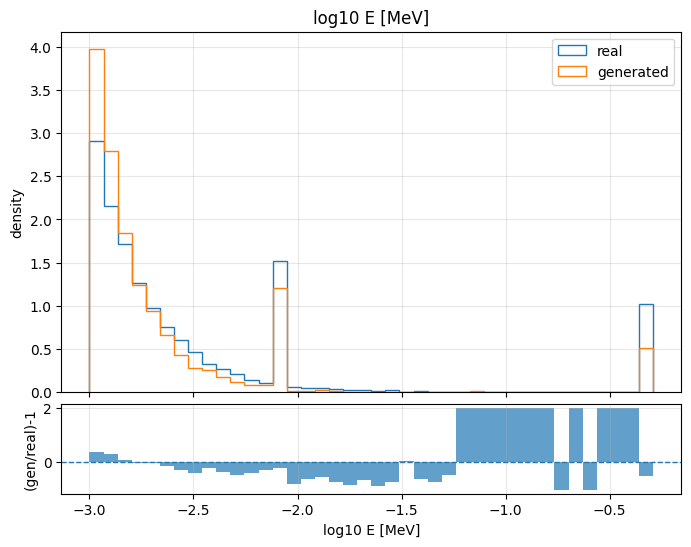

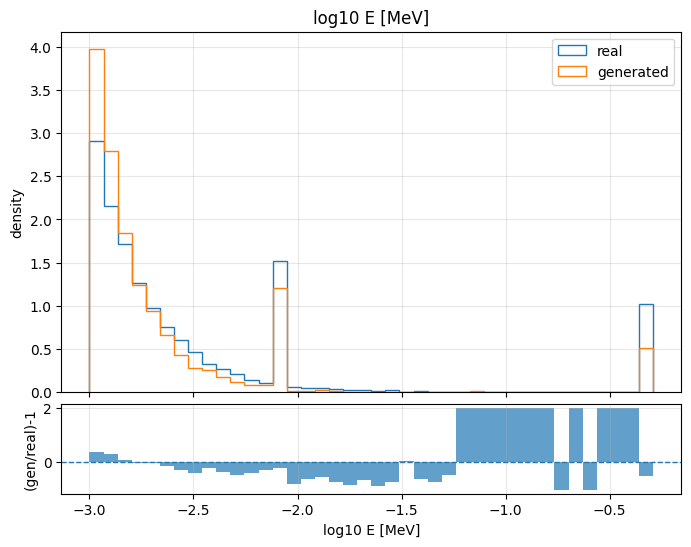

In [19]:
magi.compare_hist_with_residuals(
    np.log10(real["E"]), np.log10(gen["E"]),
    name="log10 E [MeV]", bins=40, ratio_clip=2.0,
)

## 13. Export a Geant4-ready source file

`generate_detector_table_to_file` samples straight to disk in chunks, so an
arbitrarily large source file stays memory-safe. Neutrinos are filtered out by
default; with `generate_until_n_written=True` generation continues until the
requested number of *transportable* particles has been written.

For a one-call version that also loads the checkpoint, use
`magi.generate_detector_input_file` — that is what
`scripts/generate_geant_source.py` wraps, and what the companion Geant4
project's `/generator/mlScript` macro drives.

In [20]:
OUT = os.path.join(SAVE_DIR, "example_source.dat")

summary = magi.generate_detector_table_to_file(
    model=reloaded,
    filepath=OUT,
    n_events=2000,
    type_probs=dataset_pack["type_probs"],
    n_types=dataset_pack["n_types"],
    idx_to_type=dataset_pack["idx_to_type"],
    geometry_metadata={
        "geometry_transform": "quantile_u_r_u_v_phi_r_phi_v",
        "qt_u_r": qt["qt_u_r"], "qt_u_v": qt["qt_u_v"],
        "qt_phi_r": qt["qt_phi_r"], "qt_phi_v": qt["qt_phi_v"],
    },
    energy_head_mode="mixture",
    energy_transform="log10",
    center=center, radius=R,
    chunk_size=1000, seed=42,
    output_format="text",
    verbose=1,
)

print("\nfirst 3 lines of the source file:")
with open(OUT) as f:
    for _ in range(3):
        print("  ", f.readline().rstrip())

[MAGI] Generating chunk attempted=0 written=0 / target=2000
[MAGI] Generating chunk attempted=1000 written=1000 / target=2000
[MAGI] Saved generated detector text file to /var/folders/l7/67sx0h9j2zz3l3b80sx34dj00000gn/T/magi_example_run/example_source.dat
[MAGI] Raw generated samples attempted: 2000
[MAGI] Transport particles written: 2000

first 3 lines of the source file:
   e-	1.58298993e-03	9.99845691e+00	1.50045910e+01	-5.86540804e+01	9.07702503e-01	4.19593290e-01	-4.19956601e-03
   gamma	1.23276934e-03	-1.76029411e+01	9.27030708e+00	-4.79511296e+01	8.71626103e-01	3.08144257e-01	3.81202115e-01
   e-	1.08822179e-03	-4.44503810e+00	2.45127526e+00	-6.93450998e+01	-8.76672165e-01	3.67896190e-01	3.09997271e-01


## 14. Visualize the trained run

Two `magi.utils` functions write a self-contained, interactive HTML file for
looking inside a trained v0.8 mixture model -- open it in any browser, no
server or plotting library needed.

- **`save_routing_circuit`** reads only the checkpoint's own saved
  config/metadata (no raw data, no loaded model), so it runs in under a
  second. It needs `prior_zone_conditioning=True` at training time, which
  this run has (Section 8) -- a checkpoint without it has no `zone_probs` to
  plot and raises `KeyError`.
- **`save_full_circuit`** needs a real held-out sample to trace, which a
  checkpoint alone does not carry, so it re-derives the training-time
  preprocessing (line matching, gate targets, quantile/log10 transforms, the
  train/test split) from a raw detector table -- the same file-based
  interface you would use on real data. This toy source only exists as an
  in-memory DataFrame, so the cell below writes it out once with
  `save_detector_table`/`save_candidate_energy_lines` first, exactly what a
  real `.dat` file and candidate-lines JSON look like.

In [21]:
magi.save_routing_circuit(save_dir=SAVE_DIR, model_name=MODEL_NAME)

Saved routing circuit to: /var/folders/l7/67sx0h9j2zz3l3b80sx34dj00000gn/T/magi_example_run/example_mix_routing_circuit.html


'/var/folders/l7/67sx0h9j2zz3l3b80sx34dj00000gn/T/magi_example_run/example_mix_routing_circuit.html'

In [22]:
# save_full_circuit expects real file paths (the same interface you'd use
# against a real .dat file and candidate-lines JSON) -- write this toy
# source out once so the call below is representative of real usage.
RAW_DATA_PATH = os.path.join(SAVE_DIR, "example_source_raw.dat")
CANDIDATE_LINES_PATH = os.path.join(SAVE_DIR, "example_candidate_lines.json")

magi.save_detector_table(df, RAW_DATA_PATH, include_event_id=True)
magi.save_candidate_energy_lines({"lines": candidate_lines}, CANDIDATE_LINES_PATH)

magi.save_full_circuit(
    save_dir=SAVE_DIR, model_name=MODEL_NAME,
    training_data_filepath=RAW_DATA_PATH,
    candidate_lines_file=CANDIDATE_LINES_PATH,
    center=center, radius=R, resolution_ev=RESOLUTION_EV,
    # Matched to this toy source's own scale (Section 4) rather than the
    # production defaults (512 bins / 10,000 quantiles), which assume a
    # multi-million-event real source.
    energy_bins=64, n_quantiles=1000,
    spectrum_log_range=(-3.1, 1.4),
)

Saved detector table to: /var/folders/l7/67sx0h9j2zz3l3b80sx34dj00000gn/T/magi_example_run/example_source_raw.dat
Rows saved: 7200
Columns: ['EventId', 'ParticleName', 'Energy', 'X', 'Y', 'Z', 'Vx', 'Vy', 'Vz']
Saved candidate energy lines to: /var/folders/l7/67sx0h9j2zz3l3b80sx34dj00000gn/T/magi_example_run/example_candidate_lines.json


Saved full circuit trace to: /var/folders/l7/67sx0h9j2zz3l3b80sx34dj00000gn/T/magi_example_run/example_mix_full_circuit.html


'/var/folders/l7/67sx0h9j2zz3l3b80sx34dj00000gn/T/magi_example_run/example_mix_full_circuit.html'

## Next steps

- **`docs/manual/magi_manual.pdf`** — the full user manual: code structure, the
  API and its settings, the tools, a worked full run, a worked validation, the
  theoretical foundation, and the validity envelope.
- **`MAGI_package/docs/USAGE.md`** — the short-form version of the same.
- **`tools/run_v0_8_real.py`** — a real run on real data, with live logging.
- **`tools/acceptance_v0_8.py`** — the pass/fail harness. Always use
  `--seeds 42 7 13`: on the cosmic-ray source the per-band Wasserstein has a
  seed-to-seed σ/μ of 40–50%, and two changes adopted on single-seed evidence
  during development both evaporated under a three-seed grid.
- **`docs/v0.8.1_line_truth.md`** — the measurement record: what was tried, what
  it showed, and what has already been ruled out.

### Before you trust a number

This walkthrough is a mechanical demonstration. On real data:

- Coupling and the energy marginal are validated, with error bars.
- Per-line **intensities** are not — 0.7× to 4.9×, unstable across seeds. Do not
  use generated output to estimate a line flux.
- Line **positions** are reliable, audited to ≤0.5 eV.
- Geometry is hard-limited to a **sphere**.
- `geometry_transform` mismatches between training and generation do not raise;
  they produce physically wrong output.